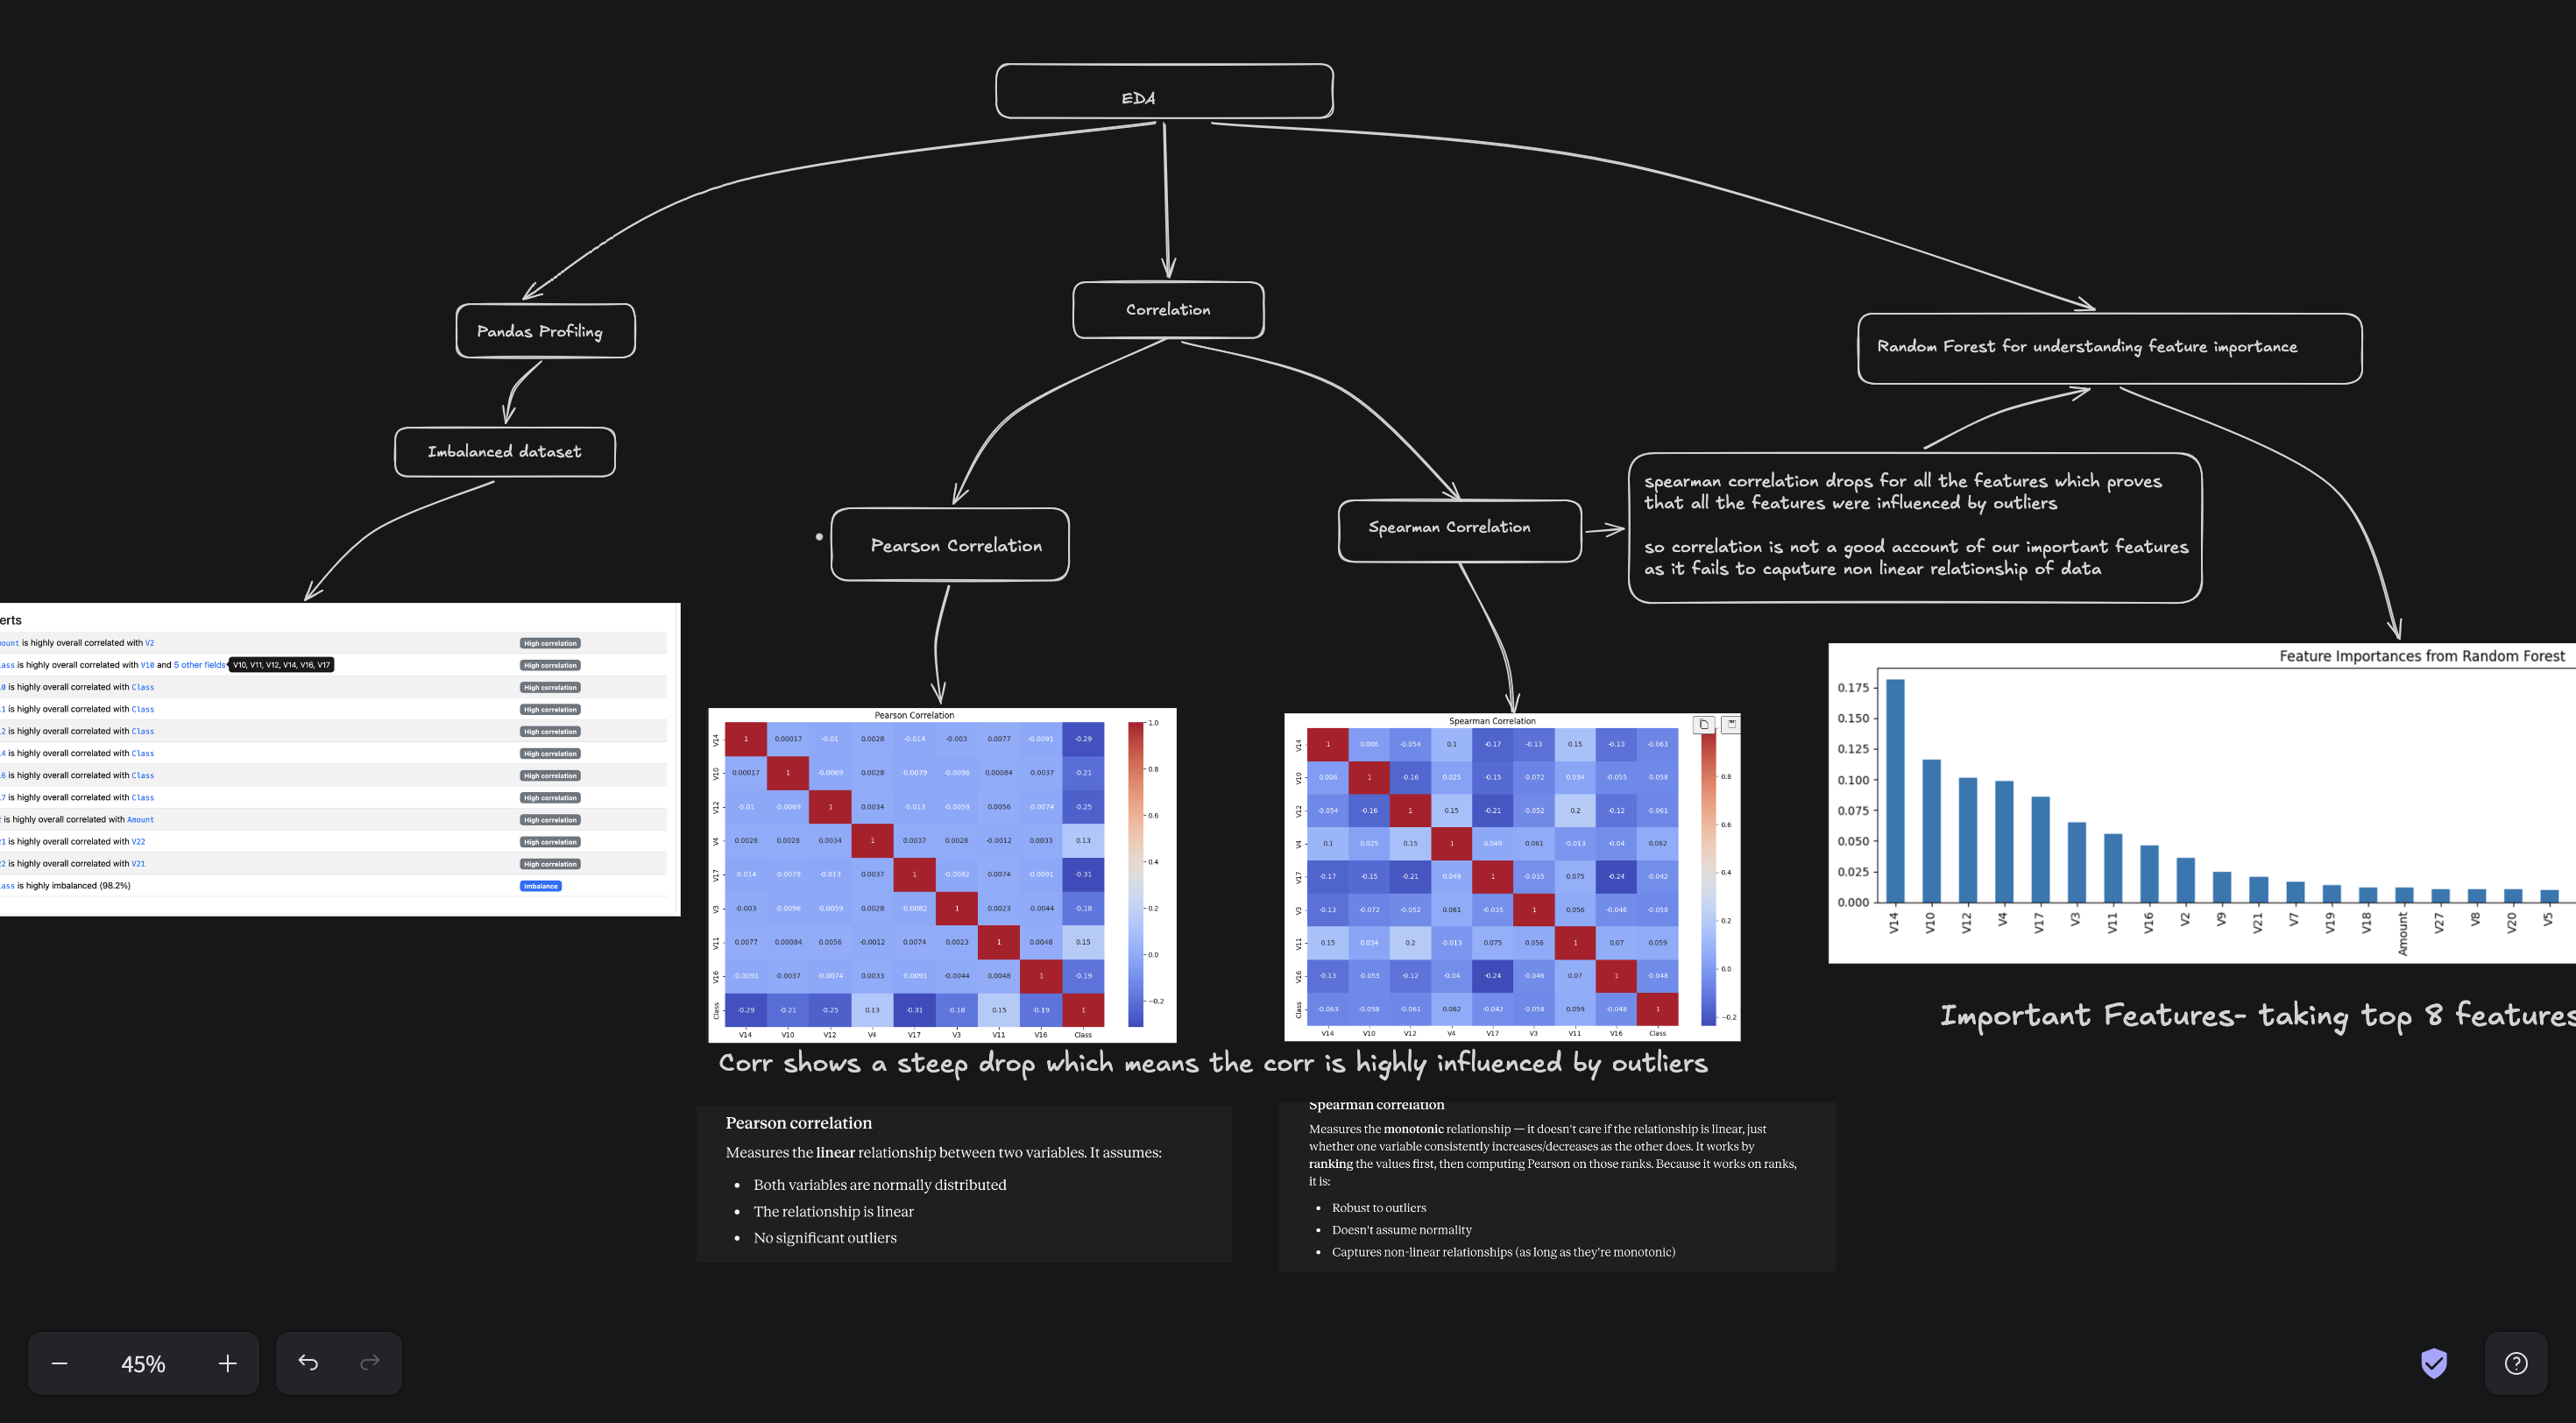

In [10]:
import numpy as np 
import pandas as pd

from ydata_profiling import ProfileReport

import matplotlib.pyplot as plt
import seaborn as sns



# Loading the dataset and understanding its dimmension

In [2]:
df=pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.sample(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
172737,121221.0,-0.607549,-0.999701,-2.095909,-5.416315,2.803473,2.271774,0.529851,0.637980,0.115044,...,-0.062860,0.145264,0.168607,0.668462,-0.033718,-0.995497,0.436403,0.277180,109.99,0
106596,70029.0,-1.848454,1.951034,-2.214979,-0.180661,2.395506,3.036042,0.089019,1.148371,0.178424,...,-0.110792,0.303568,0.199179,0.993229,-0.366572,-0.371760,0.344975,0.072753,5.11,0
183373,125769.0,1.815534,0.136138,0.276085,3.919070,-0.458554,0.212076,-0.543781,0.144234,-0.144773,...,0.179580,0.543509,0.176420,0.003167,-0.273127,0.025871,0.006921,-0.028123,30.34,0
55242,46846.0,1.172687,0.370913,0.878263,2.189328,-0.117238,0.513409,-0.402942,0.238949,-0.601783,...,-0.083475,-0.333605,-0.009906,-0.544574,0.272350,-0.112073,0.011880,0.016729,3.00,0
52399,45430.0,-0.393724,1.076270,1.215160,-0.292258,0.644125,0.082382,0.696710,0.050672,-0.542230,...,-0.240912,-0.525893,-0.114636,-0.749315,-0.110568,0.148512,0.289755,0.111836,1.79,0
262078,160299.0,2.038722,-0.179165,-1.102199,0.427829,-0.239450,-1.158529,0.088295,-0.234594,0.742806,...,-0.294543,-0.789361,0.356820,-0.049679,-0.361563,0.204811,-0.077694,-0.062148,8.90,0
73674,55230.0,-3.646694,-4.243090,1.081238,0.353485,1.019920,-2.047564,-0.090798,0.244739,0.607867,...,0.544703,-0.214111,1.770414,0.325015,-0.087777,0.820445,-0.013517,0.291654,530.00,0
189143,128276.0,-1.192739,0.849666,1.584380,-1.251501,0.012731,-0.241282,0.907172,-0.759291,1.526786,...,-0.244583,-0.246185,-0.169301,0.029644,-0.439824,-0.523355,-1.785325,-1.067133,19.18,0
108452,70907.0,0.030371,1.603173,-2.217304,1.610322,1.253953,-0.125151,0.216585,0.725883,-0.363643,...,0.035721,0.325625,0.440859,-1.008099,-0.802894,-0.295564,0.081967,-0.077848,9.95,0
120539,75862.0,-0.707844,0.755911,1.284451,-1.181853,0.230116,-0.833400,1.277942,-0.165465,-1.007898,...,0.089845,0.085359,-0.148216,0.414576,0.176741,0.828138,-0.068285,0.066486,65.50,0


In [4]:
df.shape

(284807, 31)

## 2,84,807 transactions

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## EDA using Pandas Profiling


In [7]:
# 1. Drop duplicates
df = df.drop_duplicates()

print(df.shape)  # should be 284,314 rows

(283726, 31)


## Dataset Overview
- **Total transactions:** 2,84,807 (after removing 493 duplicates → 2,84,314 remain)
- **Features:** 30 total — Time, Amount, V1–V28 (PCA-transformed), Class
- **Target:** Class — binary (0 = Legit, 1 = Fraud)
- **No missing values** found in the dataset


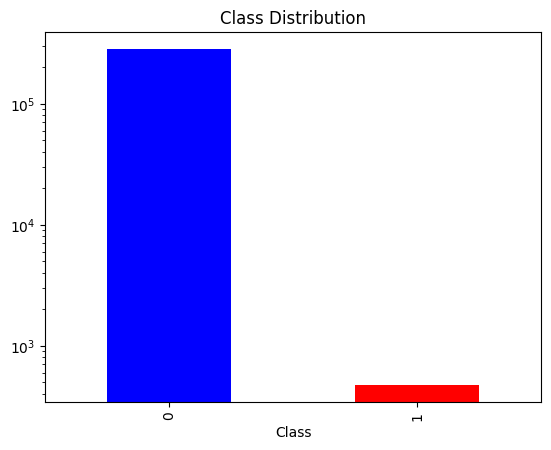

In [17]:
df['Class'].value_counts().plot(kind='bar', color=['blue','red'])
plt.title('Class Distribution')
plt.yscale('log')

In [ ]:
prof= ProfileReport(df, pool_size=0)
prof.to_file(output_file='../EDA/output.html')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 14.99it/s]


In [8]:
# 2. Check class distribution
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


## 1. Class Imbalance
- **Legit:** 2,84,315 transactions → ~**99.83%**
- **Fraud:** 492 transactions → ~**0.17%**
- Dataset is **severely imbalanced** — confirmed by Pandas Profiling alert (98.2% imbalance)
- Any model trained without handling this imbalance will be biased toward predicting Legit for everything and still achieve 99%+ accuracy — which is misleading

In [9]:
# 3. Separate fraud vs legit for visual EDA
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]
print(f"Fraud: {len(fraud)}, Legit: {len(legit)}")

Fraud: 473, Legit: 283253


In [ ]:
fraud_profile = ProfileReport(fraud, title="Fraud",pool_size=1)
legit_profile = ProfileReport(legit, title="Legit",pool_size=1)

comparison = fraud_profile.compare(legit_profile)
comparison.to_file("../EDA/fraud_vs_legit.html")

/Users/moksh/Documents/Project/.venv/lib/python3.11/site-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)
Summarize dataset:  87%|████████▋ | 33/38 [00:09<00:01,  3.67it/s, Calculate auto correlation]

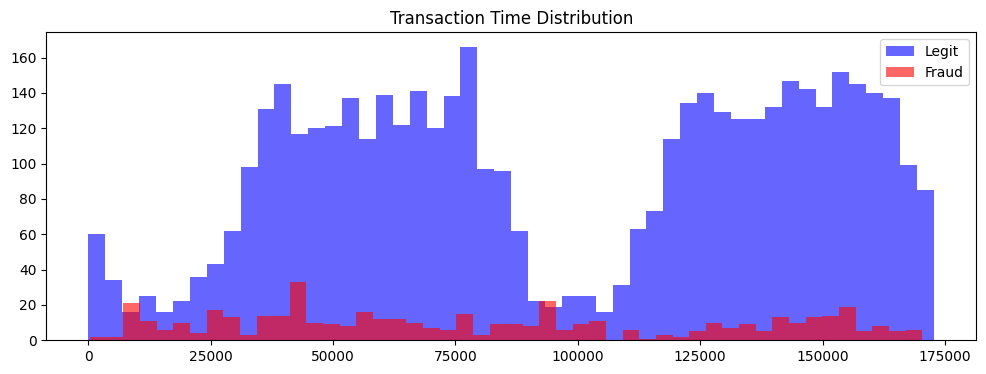

In [14]:
plt.figure(figsize=(12,4))
plt.hist(legit['Time'].sample(len(fraud)*10), bins=50, alpha=0.6, label='Legit', color='blue')
plt.hist(fraud['Time'], bins=50, alpha=0.6, label='Fraud', color='red')

plt.title('Transaction Time Distribution')
plt.legend()
plt.show()

## 2. Transaction Time Distribution
- Legit transactions show **two clear activity peaks**, consistent with two days of data — high activity during daytime, sharp drop overnight
- Fraud transactions are **uniformly spread across time** — fraudsters operate at all hours including quiet overnight periods
- **Insight:** The fraud-to-legit ratio is higher during low-activity hours (overnight), making time-of-day a useful engineered feature
- Time alone is a weak predictor, but hour_of_day derived from it could be meaningful

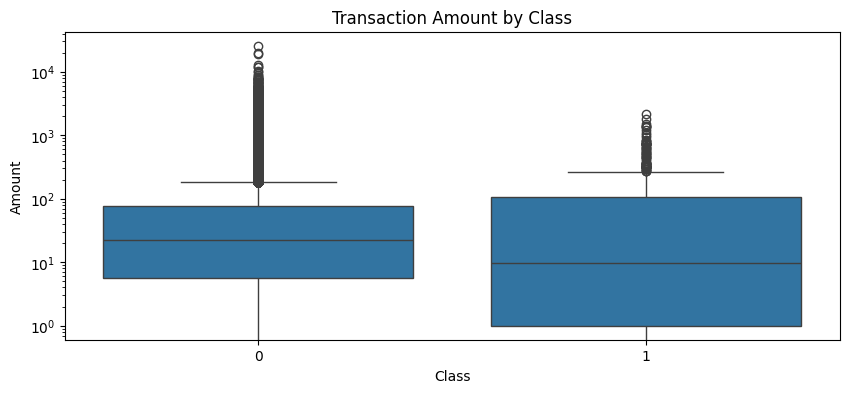

In [12]:
plt.figure(figsize=(10,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.yscale('log')
plt.title('Transaction Amount by Class')
plt.show()

## we will extract all the important features using random forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

X = df.drop('Class', axis=1)
y = df['Class']

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
rf.feature_importances_

array([0.00462443, 0.00665357, 0.03586184, 0.06527766, 0.09903385,
       0.00997379, 0.00629965, 0.01642326, 0.01072027, 0.02447406,
       0.1160603 , 0.05567345, 0.1015101 , 0.00776137, 0.18152986,
       0.00749949, 0.04622948, 0.0860178 , 0.01194871, 0.01375506,
       0.01062952, 0.02049534, 0.00593171, 0.00758824, 0.00422441,
       0.0051172 , 0.0083855 , 0.01086958, 0.00756641, 0.01186411])

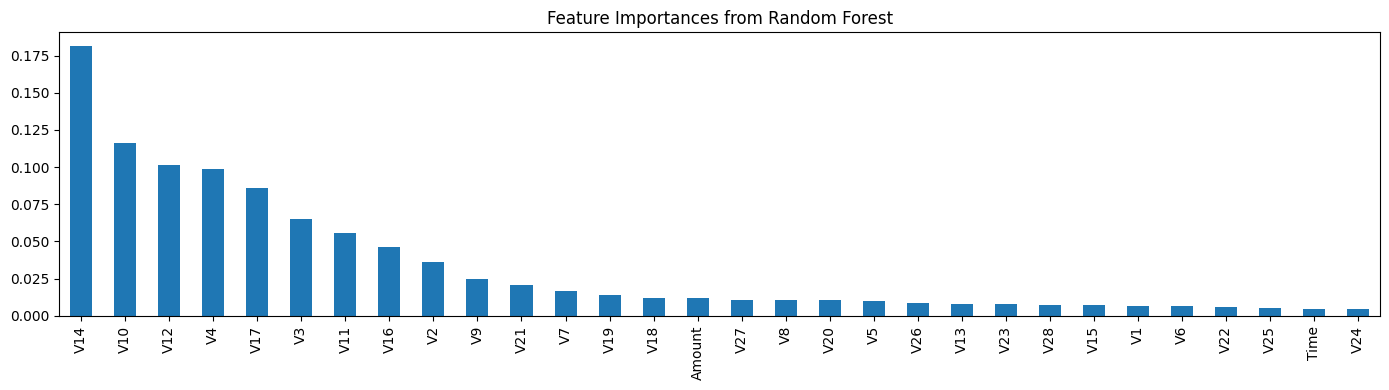

V14       0.181530
V10       0.116060
V12       0.101510
V4        0.099034
V17       0.086018
V3        0.065278
V11       0.055673
V16       0.046229
V2        0.035862
V9        0.024474
V21       0.020495
V7        0.016423
V19       0.013755
V18       0.011949
Amount    0.011864
V27       0.010870
V8        0.010720
V20       0.010630
V5        0.009974
V26       0.008386
V13       0.007761
V23       0.007588
V28       0.007566
V15       0.007499
V1        0.006654
V6        0.006300
V22       0.005932
V25       0.005117
Time      0.004624
V24       0.004224
dtype: float64

In [26]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(14,4))
plt.title('Feature Importances from Random Forest')
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)

Both methods agree on most features, but V3 and V4 only showed up as important in the Random Forest — meaning their relationship with fraud is non-linear and can't be picked up by simple correlation

## We will take top 8 features of further EDA

In [27]:
top_features = importances.sort_values(ascending=False).head(8).index.tolist()
print(top_features)

['V14', 'V10', 'V12', 'V4', 'V17', 'V3', 'V11', 'V16']


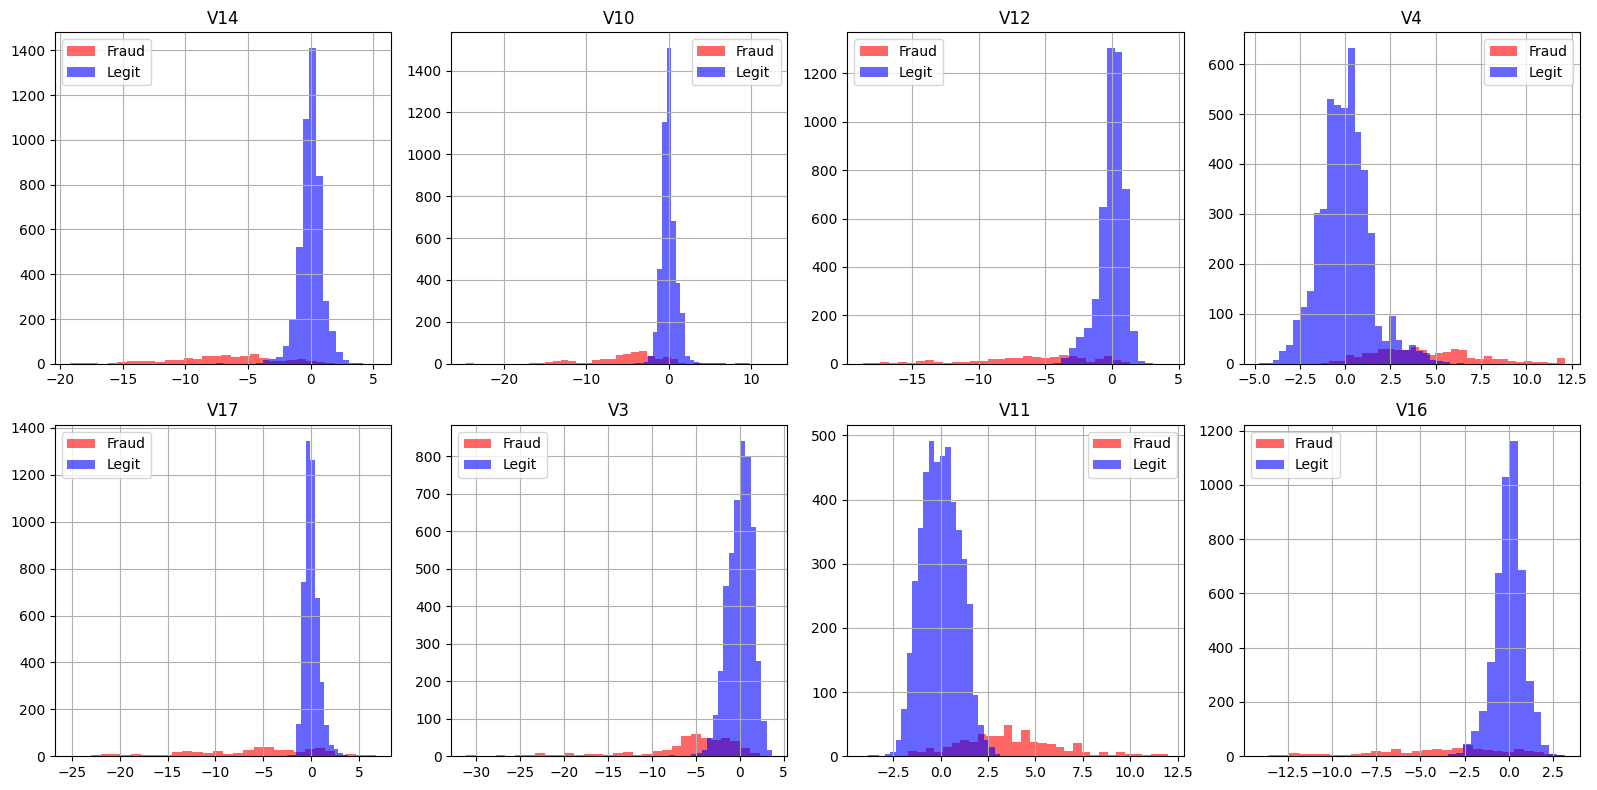

In [28]:

fig, axes = plt.subplots(2, 4, figsize=(16,8))
for i, feat in enumerate(top_features):
    ax = axes[i//4][i%4]
    fraud[feat].hist(bins=30, alpha=0.6, color='red', label='Fraud', ax=ax)
    legit[feat].sample(len(fraud)*10).hist(bins=30, alpha=0.6, color='blue', label='Legit', ax=ax)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

## 4. PCA Feature Distributions (V14, V17, V12, V10, V16, V11, V18)
- **Legit transactions** cluster tightly around **zero** for all V features — low variance, single dominant peak
- **Fraud transactions** spread widely, often skewed toward the **negative tail**
- Exception: **V11** — fraud spreads toward the **positive tail** (right side)
- Fraud distributions show **multiple peaks** (multimodal) — suggesting fraud is not a single homogeneous group but contains **distinct fraud subtypes or strategies**

<Axes: >

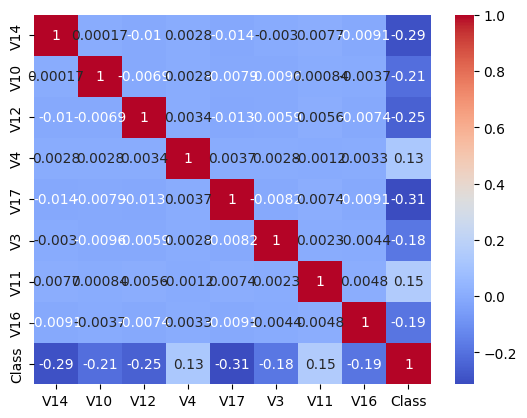

In [30]:
sns.heatmap(df[top_features + ['Class']].corr(), annot=True, cmap='coolwarm')

# the corr we used was pearson now we will use spearman correlation to see the impact of outliers

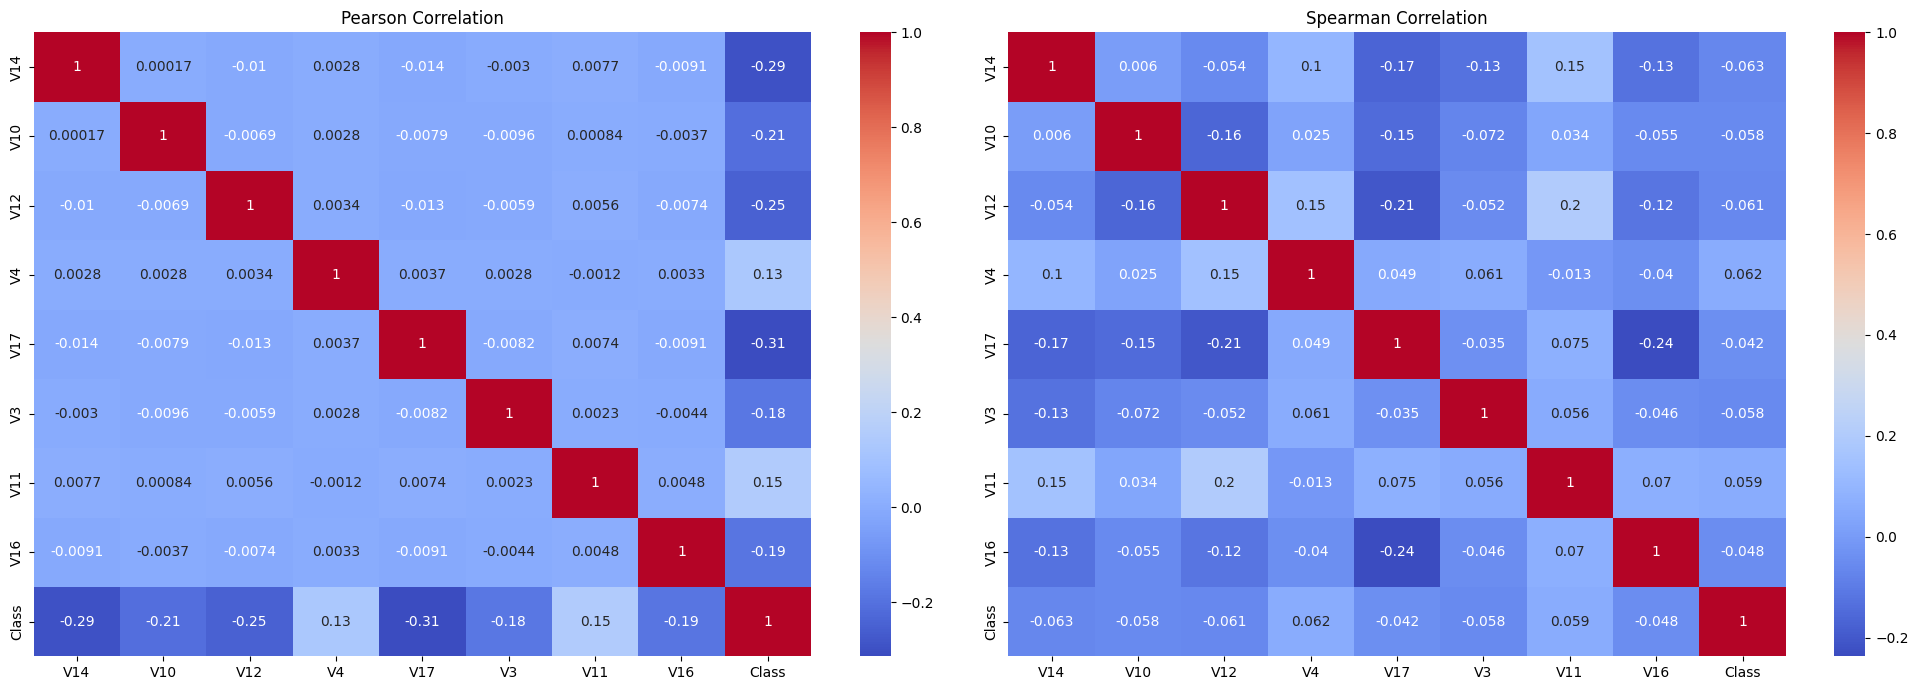

In [32]:
pythonfig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.heatmap(df[top_features + ['Class']].corr(method='pearson'), 
            annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Pearson Correlation')

sns.heatmap(df[top_features + ['Class']].corr(method='spearman'), 
            annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Spearman Correlation')

plt.tight_layout()
plt.show()

## Corr shows a steep drop which means the corr is highly influenced by outliers